In [ ]:
# Social Stratification Analysis

## Aim
To analyse how social standing influences mental health outcomes.

In [29]:
# Import files
from google.colab import files
uploaded = files.upload()


Saving race_detention.csv to race_detention (3).csv


In [30]:
from google.colab import files
uploaded = files.upload()

Saving deprivation_detention.csv to deprivation_detention (1).csv


In [31]:
from google.colab import files
uploaded = files.upload()

Saving age_detention.csv to age_detention (3).csv


In [32]:
from google.colab import files
uploaded = files.upload()

Saving race_deprivation_detention.csv to race_deprivation_detention (1).csv


In [33]:
from google.colab import files
uploaded = files.upload()

Saving race_age_detention.csv to race_age_detention (1).csv


In [40]:
# Load CSV files and label files

import pandas as pd
import matplotlib.pyplot as plt

race = pd.read_csv("race_detention.csv")
age = pd.read_csv("age_detention.csv", skiprows=7, header=0)
deprivation = pd.read_csv("deprivation_detention.csv")
race_deprivation = pd.read_csv("race_deprivation_detention.csv")
race_age = pd.read_csv("race_age_detention.csv")

In [35]:
# Preview files and make sure they are readable
race.head()

,Year,Race,life satiscation (mean score out of ten),"Detention Rate (per 100,000 population)"
0,2022-23,White,7.47,65.162470
1,2022-23,Black,7.14,224.543419
2,2022-23,Asian,7.46,71.888841
3,2022-23,Mixed,6.94,102.673587
4,2022-23,Other,7.22,112.207894


In [44]:
# fix heading problem
age = pd.read_csv("age_detention.csv", skiprows=7)

age.columns = age.iloc[0]
age = age[1:].reset_index(drop=True)

age["Detention Rate (per 100,000 population)"] = pd.to_numeric(
    age["Detention Rate (per 100,000 population)"]
)

age.head()

,Year,Age,"Detention Rate (per 100,000 population)"
0,2022-23,15 and under,3.023918
1,2022-23,16 to 17,52.652037
2,2022-23,18 to 34,135.893387
3,2022-23,35 to 49,115.517313
4,2022-23,50 to 64,89.269656


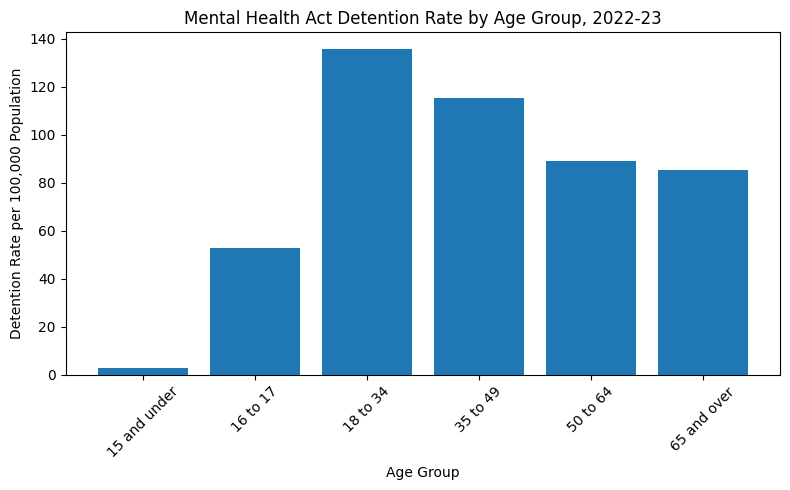

In [45]:
# Age x Detention Graph

plt.figure(figsize=(8,5))
plt.bar(age["Age"], age["Detention Rate (per 100,000 population)"])
plt.title("Mental Health Act Detention Rate by Age Group, 2022-23")
plt.xlabel("Age Group")
plt.ylabel("Detention Rate per 100,000 Population")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
# Race x Life Satisfaction x Detentions

import pandas as pd
import matplotlib.pyplot as plt

# Load data
race = pd.read_csv("race_detention.csv")

# Check column names
race.head()

,Year,Race,life satiscation (mean score out of ten),"Detention Rate (per 100,000 population)"
0,2022-23,White,7.47,65.162470
1,2022-23,Black,7.14,224.543419
2,2022-23,Asian,7.46,71.888841
3,2022-23,Mixed,6.94,102.673587
4,2022-23,Other,7.22,112.207894


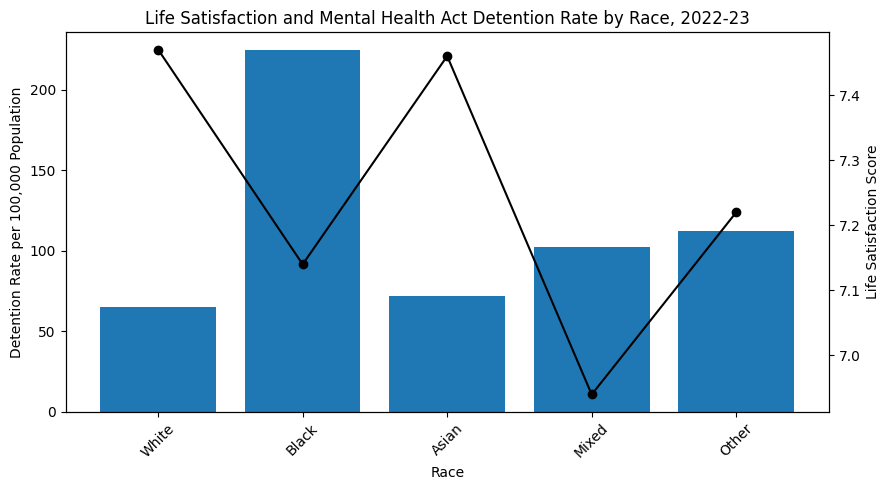

In [ ]:
# Create figure and first axis
fig, ax1 = plt.subplots(figsize=(9, 5))

# Bar chart: detention rate
ax1.bar(
    race["Race"],
    race["Detention Rate (per 100,000 population)"],
    label="Detention Rate"
)

ax1.set_xlabel("Race")
ax1.set_ylabel("Detention Rate per 100,000 Population")
ax1.tick_params(axis="x", rotation=45)

# Create second axis for life satisfaction
ax2 = ax1.twinx()

# Scatter/line: life satisfaction
ax2.plot(
    race["Race"],
    race["life satiscation (mean score out of ten)"],
    marker="o",
    label="Life Satisfaction",
    color="black"
)

ax2.set_ylabel("Life Satisfaction Score")

# Title
plt.title("Life Satisfaction and Mental Health Act Detention Rate by Race, 2022-23")

# Layout
fig.tight_layout()

# Save graph
plt.savefig("race_life_satisfaction_detention_graph.png", dpi=300, bbox_inches="tight")

# Show graph
plt.show()

In [73]:
correlation_ls_detention = race['life satiscation (mean score out of ten)'].corr(race['Detention Rate (per 100,000 population)'])
print(f"Correlation between Life Satisfaction and Detention Rate: {correlation_ls_detention:.2f}")

Correlation between Life Satisfaction and Detention Rate: -0.49


### Insight

The correlation coefficient between Life Satisfaction and Detention Rate is -0.49. This indicates a moderate negative correlation. In general, as life satisfaction increases, the detention rate tends to decrease.

Overall, while a general inverse trend between life satisfaction and detention rates might be suggested for some groups, the most striking observation is the significant racial disparity, particularly the elevated detention rates for within the Race 'Black', which cannot be solely explained by life satisfaction levels.

In [56]:
# Preview csv and make sure the file is readable

deprivation.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2'], dtype='object')

In [58]:
# Diagnostics

deprivation

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN


In [61]:
deprivation = pd.read_csv(
    "deprivation_detention.csv",
    skiprows=16
)

In [62]:
deprivation.head()

,Year,IMD Decile,"Detention Rate (per 100,000 population)"
0,2022-23,01 Least deprived,40.091273
1,2022-23,02 Less deprived,47.386881
2,2022-23,03 Less deprived,55.958106
3,2022-23,04 Less deprived,61.179380
4,2022-23,05 Less deprived,70.103314


In [63]:
deprivation.columns

Index(['Year', 'IMD Decile ', 'Detention Rate (per 100,000 population)'], dtype='object')

In [64]:
deprivation["Detention Rate (per 100,000 population)"] = pd.to_numeric(
    deprivation["Detention Rate (per 100,000 population)"]
)

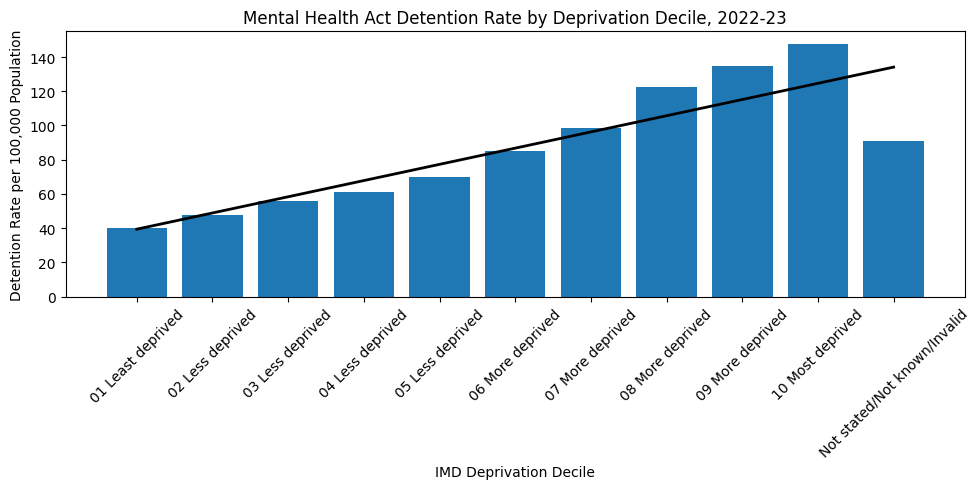

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Re-load deprivation data to ensure correct headers
deprivation = pd.read_csv(
    "deprivation_detention.csv",
    skiprows=16
)

# Clean column names by stripping whitespace
deprivation.columns = deprivation.columns.str.strip()

# Create x positions
x = np.arange(len(deprivation))

# Convert detention rates to numeric
y = deprivation["Detention Rate (per 100,000 population)"].astype(float)

# Create line of best fit
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Plot
plt.figure(figsize=(10,5))

# Bars
plt.bar(
    deprivation["IMD Decile"],
    y
)

# Best fit line
plt.plot(
    deprivation["IMD Decile"],
    p(x),
    linewidth=2,
    color='black' # Moved and corrected the color argument here
)

plt.title("Mental Health Act Detention Rate by Deprivation Decile, 2022-23")
plt.xlabel("IMD Deprivation Decile")
plt.ylabel("Detention Rate per 100,000 Population")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "deprivation_detention_best_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
# Extract numeric decile from 'IMD Decile' for correlation calculation
deprivation['IMD_Decile_Numeric'] = deprivation['IMD Decile'].str.extract(r'^(\d+)').astype(float)

# Calculate the Pearson correlation
correlation = deprivation['IMD_Decile_Numeric'].corr(deprivation['Detention Rate (per 100,000 population)'])

print(f"Correlation between IMD Decile and Detention Rate: {correlation:.2f}")

Correlation between IMD Decile and Detention Rate: 0.98


### Insight
Detention rates increase progressively with deprivation, suggesting that socioeconomic disadvantage may be associated with a greater likelihood of reaching crisis-level mental health intervention.

The high correlation coefficient of 0.98 between the IMD (Index of Multiple Deprivation) Decile and the Mental Health Act Detention Rate indicates a very strong positive linear relationship. This suggests that socio-economic deprivation is a major factor influencing mental health outcomes that lead to detention under the Mental Health Act.

In [75]:
# Check the readablity of 'race x age'

race_age

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
# Diagnostic (fix titles and row readability)
race_deprivation = pd.read_csv(
    "race_age_detention.csv",
    skiprows=30
)

In [79]:
race_deprivation.head()
race_deprivation.columns

Index(['Race', '01 Least deprived\n (%)', '02 Less deprived\n (%)',
       '03 Less deprived\n (%)', '04 Less deprived\n (%)',
       '05 Less deprived\n (%)', '06 More deprived\n (%)',
       '07 More deprived\n (%)', '08 More deprived\n (%)',
       '09 More deprived\n (%)', '10 Most deprived\n (%)',
       'Not stated/Not known/Invalid\n (%)'],
      dtype='object')

In [82]:
# Clean column names for better readability (optional, but good practice)
race_deprivation.columns = race_deprivation.columns.str.replace(r'\n \(%\)', '', regex=True).str.strip()

# Convert all values to numeric by first removing the '%' character
for col in race_deprivation.columns:
    race_deprivation[col] = race_deprivation[col].str.replace('%', '', regex=False).astype(float)

race_deprivation.head()

,01 Least deprived,02 Less deprived,03 Less deprived,04 Less deprived,05 Less deprived,06 More deprived,07 More deprived,08 More deprived,09 More deprived,10 Most deprived,Not stated/Not known/Invalid
Race,,,,,,,,,,,
White,5.2,5.9,7.0,7.3,8.1,9.5,10.2,11.8,13.5,16.4,5.0
Mixed,2.4,4.4,5.6,5.1,8.4,8.6,11.5,15.4,17.8,15.7,5.0
Asian or Asian British,2.5,2.8,3.6,4.7,6.4,8.4,12.2,17.4,18.5,19.5,3.9
Black or Black British,1.1,1.7,2.5,3.7,5.0,9.5,13.0,21.0,21.1,15.9,5.5
Other Ethnic Groups,2.9,3.5,3.8,6.0,6.7,9.7,13.2,15.9,16.1,15.0,7.3


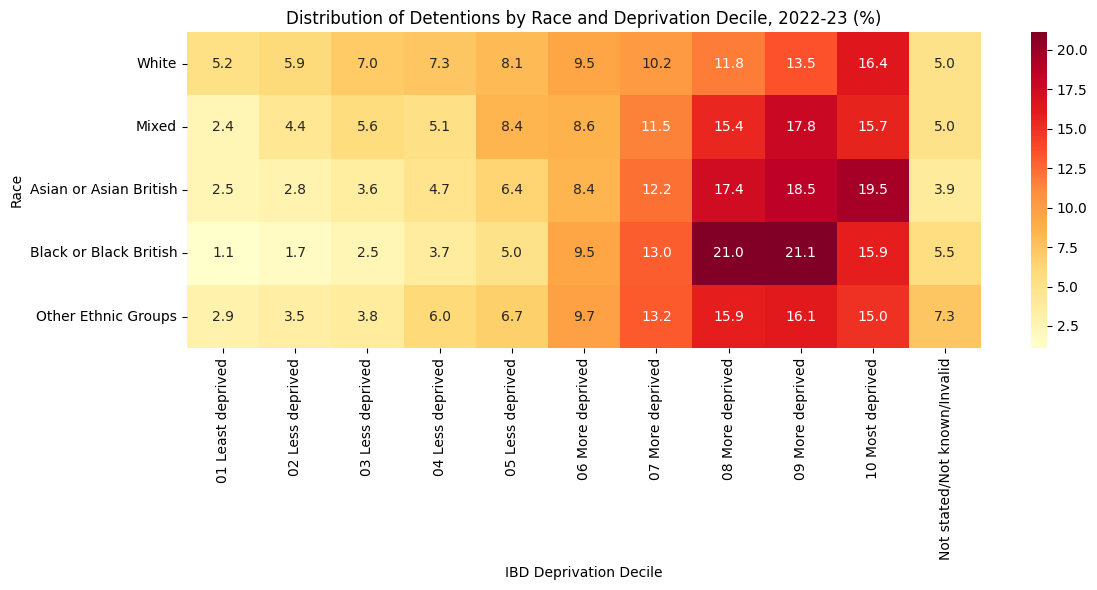

In [86]:
# Create Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    race_deprivation,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Distribution of Detentions by Race and Deprivation Decile, 2022-23 (%)")
plt.xlabel("IBD Deprivation Decile")
plt.ylabel("Race")

plt.tight_layout()

plt.savefig(
    "race_deprivation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Average Detention Rates for Most and Least Deprived Groups

In [84]:
average_least_deprived = race_deprivation['01 Least deprived'].mean()
average_most_deprived = race_deprivation['10 Most deprived'].mean()

print(f"Average detention rate for '01 Least deprived': {average_least_deprived:.2f}%")
print(f"Average detention rate for '10 Most deprived': {average_most_deprived:.2f}%")

Average detention rate for '01 Least deprived': 2.82%
Average detention rate for '10 Most deprived': 16.50%


The average detention rate for the '01 Least deprived' group is 2.82%, while for the '10 Most deprived' group it is 16.50%. This indicates a significant difference in detention rates between the most and least deprived populations.



## T-Test: Least Deprived vs. Most Deprived Detention Rates

In [85]:
from scipy import stats

# Extract the detention rates for the 'Least deprived' and 'Most deprived' groups
least_deprived_rates = race_deprivation['01 Least deprived']
most_deprived_rates = race_deprivation['10 Most deprived']

# Perform independent t-test
t_statistic, p_value = stats.ttest_ind(least_deprived_rates, most_deprived_rates)

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print("\nThe difference in detention rates between the least and most deprived groups is statistically significant.")
else:
    print("\nThe difference in detention rates between the least and most deprived groups is not statistically significant.")

T-statistic: -13.30
P-value: 0.000

The difference in detention rates between the least and most deprived groups is statistically significant.


### Insight

Since the p-value (0.000) is much less than the conventional significance level (alpha = 0.05), we can conclude that the difference in detention rates between the least and most deprived groups is statistically significant. This reinforces the observation that detention rates are substantially higher in the most deprived areas compared to the least deprived areas.

In [91]:
# Check the readability of 'race x age'

race_age

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
# Diagnostic

import os
os.listdir()

['.config',
 'deprivation_detention.csv',
 'age_detention (2).csv',
 'deprivation_detention_best_fit.png',
 'race_deprivation_heatmap.png',
 'race_age_detention.csv',
 'race_life_satisfaction_detention_graph.png',
 'deprivation_detention (1).csv',
 'race_detention (3).csv',
 'age_detention (1).csv',
 'race_deprivation_detention.csv',
 'race_detention.csv',
 'race_deprivation_detention (1).csv',
 'age_detention (3).csv',
 'age_detention.csv',
 'race_age_detention (1).csv',
 'race_detention (1).csv',
 'race_detention (2).csv',
 'sample_data']

In [98]:
race_age = pd.read_csv("race_age_detention (1).csv")

In [101]:
race_age

,15 and under (%),16 to 17 (%),18 to 34 (%),35 to 49 (%),50 to 64 (%),65 and over (%)
Race,,,,,,
White,0.664335,1.360763,28.832761,24.320421,21.608524,23.213197
Mixed,1.603982,2.765487,49.612832,26.880531,12.997788,6.139381
Asian or Asian British,0.426667,1.493333,41.386667,33.413333,15.546667,7.733333
Black or Black British,0.429646,1.002506,44.951665,29.072682,19.441461,5.102041
Other Ethnic Groups,0.565262,1.747174,47.995889,29.393628,13.309353,6.988695


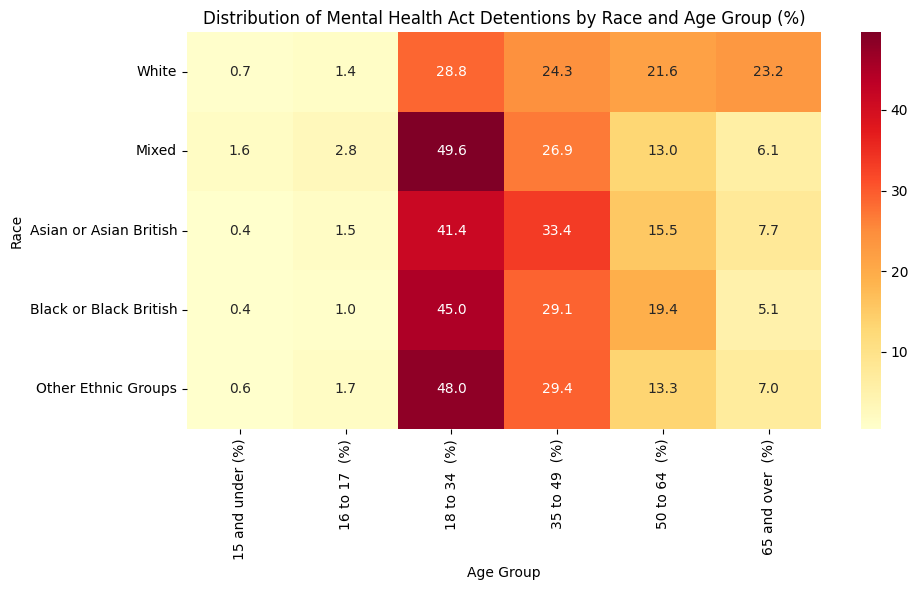

In [100]:
# Create heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Set race as row labels
race_age = race_age.set_index("Race")

# Convert all values to numbers
race_age = race_age.apply(pd.to_numeric)

plt.figure(figsize=(10,6))

sns.heatmap(
    race_age,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Distribution of Mental Health Act Detentions by Race and Age Group (%)")
plt.xlabel("Age Group")
plt.ylabel("Race")

plt.tight_layout()

plt.savefig(
    "race_age_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparative Statistics for Race and Age Detention

In [102]:
# Calculate the average detention rate for each race across all age groups
average_detention_by_race = race_age.mean(axis=1).sort_values(ascending=False)

print("Average Detention Rate by Race (across all age groups):\n")
print(average_detention_by_race)

# Calculate the average detention rate for each age group across all races
average_detention_by_age_group = race_age.mean(axis=0).sort_values(ascending=False)

print("\nAverage Detention Rate by Age Group (across all races):\n")
print(average_detention_by_age_group)

Average Detention Rate by Race (across all age groups):

Race
White                     16.666667
Asian or Asian British    16.666667
Mixed                     16.666667
Black or Black British    16.666667
Other Ethnic Groups       16.666667
dtype: float64

Average Detention Rate by Age Group (across all races):

18 to 34  (%)       42.555963
35 to 49  (%)       28.616119
50 to 64  (%)       16.580758
65 and over  (%)     9.835329
16 to 17  (%)        1.673853
15 and under (%)     0.737978
dtype: float64


### Summary of findings

**1. Life Satisfaction vs. Detention Rate by Race:**

A moderate negative correlation of -0.49 was found between life satisfaction and detention rate, suggesting that generally, as life satisfaction increases, the detention rate tends to decrease.
However, a significant racial disparity was observed, with the Black group showing disproportionately high detention rates despite moderate life satisfaction.


**2. Detention Rate by Deprivation Decile:**

A very strong positive correlation of 0.98 was identified between IMD Deprivation Decile and Detention Rate, indicating that detention rates increase significantly with socio-economic deprivation.
The average detention rate for the '01 Least deprived' group was 2.82%, compared to 16.50% for the '10 Most deprived' group.
A t-test confirmed this difference as statistically significant (T-statistic: -13.30, P-value: 0.000).


**3. Distribution of Detentions by Race and Age Group (Heatmap and Comparative Statistics):**

The average detention rates by race across all age groups appeared to be uniformly around 16.67%. This suggests the race_age dataset likely contains proportional data, where each race's age distribution sums to 100%, and these averages reflect the mean of these proportions rather than absolute detention rates for each race.
Analysis of average detention rates by age group across all races revealed that the 18 to 34 age group has the highest average detention rate (42.56%), followed by 35 to 49 (28.62%).
This analysis highlights significant influences of both race and socio-economic deprivation on mental health act detention rates, with age also being a key factor in the distribution of detentions. The disproportionate rates for certain racial groups and deprived deciles warrant further investigation into underlying systemic factors.